In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.decomposition import NMF
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt

In [4]:
communication_matrix = pd.read_csv(
    "data/outputs/communication_matrix.csv",
    index_col=0
)

print(communication_matrix.shape)
communication_matrix.head()

(138, 3489)


,LGALS9→PTPRC,LGALS9→MET,LGALS9→CD44,LGALS9→LRP1,LGALS9→CD47,LGALS9→PTPRK,LGALS9→COLEC12,LGALS9→HAVCR2,LGALS9→MRC2,DLL1→NOTCH1,...,BMP6→AMHR2,GDF11→ACTR2,GDF1→ACTR2,INHBA→ACTR2,BMP7→ACTR2,BMP2→ACTR2,BMP15→ACTR2,CSF1→CSF3R,IL36G→IFNAR1,IL36G→IFNAR2
wu_natgen_CID3586,8.633867,1.044805,8.393451,0.776248,3.758318,1.168318,0.296762,3.943516,0.637201,0.292995,...,0.000000e+00,0.546232,0.0,1.127656,0.008232,0.995683,0.0,0.114970,0.000000,0.000000
wu_natgen_CID3921,7.129786,0.670546,9.661072,2.296553,5.089897,1.524040,0.145497,2.765677,0.596229,0.356648,...,0.000000e+00,0.241065,0.0,2.798962,0.346355,0.568526,0.0,0.149420,0.000000,0.000000
wu_natgen_CID45171,8.077541,0.145614,7.158105,0.689071,4.376402,1.669631,0.300532,0.799553,0.391112,0.017953,...,0.000000e+00,2.182149,0.0,0.993794,0.057089,0.080615,0.0,0.032563,0.000000,0.000000
wu_natgen_CID3838,16.582199,2.095036,17.671549,3.576852,10.819265,2.728356,1.450304,5.477222,2.551522,2.010751,...,5.337549e-06,7.685503,0.0,7.648826,0.520871,3.494657,0.0,0.315217,0.003883,0.003169
wu_natgen_CID4066,6.538203,0.480212,4.661026,1.018777,4.621882,1.056085,0.198088,1.693815,0.611983,0.456659,...,6.623769e-07,0.439607,0.0,1.183399,0.088907,0.741925,0.0,0.104455,0.000000,0.000000


In [5]:
feature_var = communication_matrix.var()

X = communication_matrix.loc[:, feature_var > 0]

print(X.shape)

(138, 3465)


In [6]:
scaler = MinMaxScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    index=X.index,
    columns=X.columns
)

X_scaled.head()

,LGALS9→PTPRC,LGALS9→MET,LGALS9→CD44,LGALS9→LRP1,LGALS9→CD47,LGALS9→PTPRK,LGALS9→COLEC12,LGALS9→HAVCR2,LGALS9→MRC2,DLL1→NOTCH1,...,BMP6→AMHR2,GDF11→ACTR2,GDF1→ACTR2,INHBA→ACTR2,BMP7→ACTR2,BMP2→ACTR2,BMP15→ACTR2,CSF1→CSF3R,IL36G→IFNAR1,IL36G→IFNAR2
wu_natgen_CID3586,0.317316,0.181536,0.329777,0.097505,0.237943,0.220291,0.073956,0.291795,0.113264,0.069562,...,0.000000,0.071073,0.0,0.147368,0.010194,0.116016,0.0,0.201122,0.000000,0.000000
wu_natgen_CID3921,0.262037,0.116508,0.379581,0.288472,0.322246,0.287363,0.036260,0.204642,0.105982,0.084674,...,0.000000,0.031366,0.0,0.365889,0.428888,0.066244,0.0,0.261387,0.000000,0.000000
wu_natgen_CID45171,0.296869,0.025301,0.281240,0.086555,0.277074,0.314815,0.074896,0.059162,0.069521,0.004262,...,0.000000,0.283931,0.0,0.129866,0.070693,0.009393,0.0,0.056963,0.000000,0.000000
wu_natgen_CID3838,0.609436,0.364016,0.694311,0.449291,0.684978,0.514441,0.361432,0.405279,0.453541,0.477388,...,0.001475,1.000000,0.0,1.000000,0.644989,0.407195,0.0,0.551421,0.019604,0.016482
wu_natgen_CID4066,0.240295,0.083438,0.183131,0.127969,0.292616,0.199129,0.049366,0.125331,0.108782,0.108419,...,0.000183,0.057200,0.0,0.154657,0.110093,0.086449,0.0,0.182728,0.000000,0.000000


In [7]:
k = 10

nmf = NMF(
    n_components=k,
    init="nndsvda",
    random_state=42,
    max_iter=1000
)

W = nmf.fit_transform(X_scaled)
H = nmf.components_

In [8]:
patient_programs = pd.DataFrame(
    W,
    index=X.index,
    columns=[f"Program_{i+1}" for i in range(k)]
)

patient_programs.head()

,Program_1,Program_2,Program_3,Program_4,Program_5,Program_6,Program_7,Program_8,Program_9,Program_10
wu_natgen_CID3586,0.241371,0.045222,0.015488,0.000000,0.179662,0.076438,0.006115,0.024802,0.00000,0.034609
wu_natgen_CID3921,0.458392,0.104045,0.005254,0.000000,0.103580,0.287554,0.016224,0.012297,0.00000,0.162021
wu_natgen_CID45171,0.232652,0.000000,0.000000,0.034655,0.046997,0.310535,0.008113,0.002387,0.00000,0.062481
wu_natgen_CID3838,0.294137,0.891904,0.002455,0.359491,0.000000,0.175819,0.000000,0.001394,0.03852,0.165139
wu_natgen_CID4066,0.184689,0.046160,0.000000,0.021896,0.202309,0.225724,0.010495,0.021510,0.01890,0.064635


In [9]:
program_features = pd.DataFrame(
    H,
    columns=X.columns,
    index=[f"Program_{i+1}" for i in range(k)]
)

program_features.head()

,LGALS9→PTPRC,LGALS9→MET,LGALS9→CD44,LGALS9→LRP1,LGALS9→CD47,LGALS9→PTPRK,LGALS9→COLEC12,LGALS9→HAVCR2,LGALS9→MRC2,DLL1→NOTCH1,...,BMP6→AMHR2,GDF11→ACTR2,GDF1→ACTR2,INHBA→ACTR2,BMP7→ACTR2,BMP2→ACTR2,BMP15→ACTR2,CSF1→CSF3R,IL36G→IFNAR1,IL36G→IFNAR2
Program_1,0.424083,0.304120,0.415414,0.442108,0.561290,0.368978,0.190259,0.202494,0.264610,0.099350,...,0.000000,0.061259,0.0,0.101291,0.007189,0.015540,0.000000,0.191015,0.0,0.000000
Program_2,0.439673,0.346086,0.488800,0.235639,0.434907,0.301995,0.186230,0.297605,0.273904,0.260943,...,0.199218,0.496136,0.0,0.638112,0.297328,0.285389,0.000000,0.431643,0.0,0.000000
Program_3,0.132759,0.000000,0.025499,0.000000,0.049636,0.004360,0.015895,0.033050,0.000000,0.000000,...,0.000000,0.096671,0.0,0.233522,0.255299,0.566787,0.417611,0.055667,0.0,0.000000
Program_4,0.085233,0.263114,0.154649,0.246441,0.057635,0.292297,0.000000,0.024513,0.310328,0.182738,...,0.000000,0.076477,0.0,0.554558,0.244493,0.100511,0.000000,0.000000,0.0,0.006497
Program_5,0.140248,0.302093,0.173422,0.055599,0.075866,0.392684,0.000000,0.050255,0.000000,0.371501,...,0.000000,0.106572,0.0,0.000000,0.000000,0.048758,0.000000,0.000000,0.0,0.000000


In [10]:
for program in program_features.index:

    print(f"\n{program}")

    display(
        program_features.loc[program]
        .sort_values(ascending=False)
        .head(20)
    )


Program_1


MIF→TNFRSF14        0.833816
HLA-DRB5→CD4        0.801298
SELPLG→ITGB2        0.765446
LTB→TNFRSF1A        0.748398
HLA-F→LILRB1        0.743895
TNFSF13→TNFRSF1A    0.709546
SELPLG→SELL         0.695465
FADD→FAS            0.692404
TNFSF13→TNFRSF14    0.687429
APP→LRP10           0.686117
HLA-G→LILRB1        0.679178
HLA-C→CD8B          0.665340
HLA-DRB1→LAG3       0.661188
APP→CD74            0.657005
HLA-A→CD8B          0.656713
HLA-B→CD8B          0.650612
HLA-DPB1→LAG3       0.649947
HLA-E→CD8B          0.648092
HLA-DPA1→LAG3       0.646675
SERPINA1→LRP1       0.645696
Name: Program_1, dtype: float64


Program_2


VEGFA→NRP1           0.715767
CD99→CD81            0.699454
TXLNA→STX4           0.692531
TGFB1→CXCR4          0.679463
CALM1→PTPRA          0.677425
PTGS2→CAV1           0.675267
ICAM4→ITGAV          0.673443
TIMP2→CD44           0.673144
VEGFB→ADRB2          0.666223
HBEGF→CD44           0.665054
ICAM4→ITGB1          0.661910
VEGFA→NRP2           0.659908
TNFSF12→TNFRSF12A    0.656006
VEGFA→SIRPA          0.655944
GNAI2→CAV1           0.650799
TNFSF9→HLA-DPA1      0.647705
ACTR2→ADRB2          0.644524
VIM→CD44             0.644387
CALR→ITGAV           0.643400
BMP2→ENG             0.642595
Name: Program_2, dtype: float64


Program_3


...

GNAI2→C5AR1          0.705740
IFNA1→CR2            0.702251
RETN→CAP1            0.688587
COL4A6→CD47          0.683845
PSG9→DSCAM           0.678078
GNAI2→FPR1           0.672707
HDC→HRH3             0.667860
GNAI2→CHRM1          0.659498
CXCL13→CCR10         0.654158
CCL7→CCR10           0.646536
FGF6→SDC4            0.639026
LGALS9→CD47          0.629745
CLEC11A→ITGA11       0.625775
HLA-A→KIR2DL3        0.624029
CCL16→HRH4           0.616808
ICAM4→ITGA4          0.614878
HDC→HRH4             0.614124
FGF23→FGFR2          0.611278
DNAJB11→PRTG         0.609433
TNFSF13→TNFRSF13B    0.604495
Name: Program_8, dtype: float64


Program_9


CALM3→EGFR      0.388576
EFEMP1→EGFR     0.379334
COL5A1→SDC3     0.374170
DCN→EGFR        0.373638
VCAN→EGFR       0.371938
APP→TNFRSF21    0.371365
TNC→SDC4        0.367128
TNC→ITGA5       0.354937
APP→LRP1        0.348741
SFRP1→FZD6      0.345955
PSAP→LRP1       0.344882
GNAI2→EGFR      0.340555
CALR→LRP1       0.339385
RGMA→BMPR2      0.339374
LRPAP1→LRP1     0.339298
CALM3→AQP6      0.338231
FGF7→FGFR4      0.337387
TNC→SDC1        0.333174
FGF11→FGFR1     0.333006
ST6GAL1→EGFR    0.331601
Name: Program_9, dtype: float64


Program_10


HLA-DRB5→CD4     0.534955
HLA-F→LILRB1     0.524606
CD14→ITGA4       0.522918
APOE→LRP1        0.499360
C1QB→LRP1        0.473347
CD14→ITGB2       0.472756
CD14→ITGB1       0.458851
PSAP→LRP1        0.428357
LGALS9→LRP1      0.425405
SIRPA→CD47       0.421736
CD47→SIRPA       0.421736
HLA-DMB→CD4      0.414681
CD86→CD28        0.410261
CD28→CD86        0.410261
SERPINA1→LRP1    0.409226
HMGB1→TLR2       0.408322
ADAM10→TREM2     0.406725
HLA-A→LILRB1     0.406666
LRPAP1→LRP1      0.404910
HLA-C→LILRB1     0.404815
Name: Program_10, dtype: float64

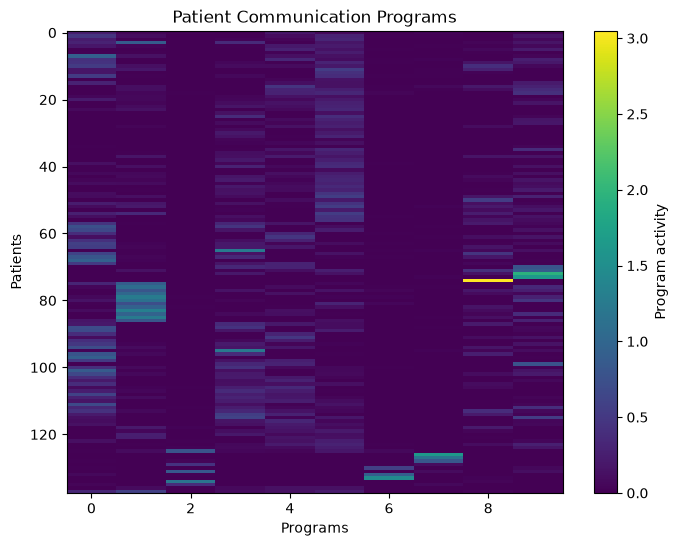

In [11]:
plt.figure(figsize=(8,6))

plt.imshow(patient_programs, aspect="auto")

plt.colorbar(label="Program activity")

plt.xlabel("Programs")
plt.ylabel("Patients")

plt.title("Patient Communication Programs")

plt.show()

In [12]:
patient_programs.to_csv(
    "data/outputs/patient_program_scores.csv"
)

program_features.to_csv(
    "data/outputs/program_feature_weights.csv"
)

print("Saved.")

Saved.


In [3]:
%who DataFrame

No variables match your requested type.


In [12]:
X_scaled = pd.read_csv(
    "data/outputs/weighted_patient_communication_matrix.csv",
    index_col=0
)

In [13]:
seeds = [0, 21, 42, 84, 168]

H_matrices = []
errors = []

for seed in seeds:

    nmf = NMF(
        n_components=10,
        init="nndsvda",
        random_state=seed,
        max_iter=1000
    )

    W = nmf.fit_transform(X_scaled)
    H = nmf.components_

    H_matrices.append(H)
    errors.append(nmf.reconstruction_err_)

print(errors)

[np.float64(31.540698059326207), np.float64(31.540698111314967), np.float64(31.54069845396787), np.float64(31.54069771462139), np.float64(31.54069811402822)]


In [14]:
from sklearn.metrics.pairwise import cosine_similarity

similarities = []

reference = H_matrices[0]

for H in H_matrices[1:]:

    sim = cosine_similarity(reference, H)

    similarities.append(sim.max(axis=1).mean())

stability = pd.DataFrame({
    "Seed": seeds[1:],
    "Mean_Cosine_Similarity": similarities,
    "Reconstruction_Error": errors[1:]
})

stability

,Seed,Mean_Cosine_Similarity,Reconstruction_Error
0,21,1.0,31.540698
1,42,1.0,31.540698
2,84,1.0,31.540698
3,168,1.0,31.540698


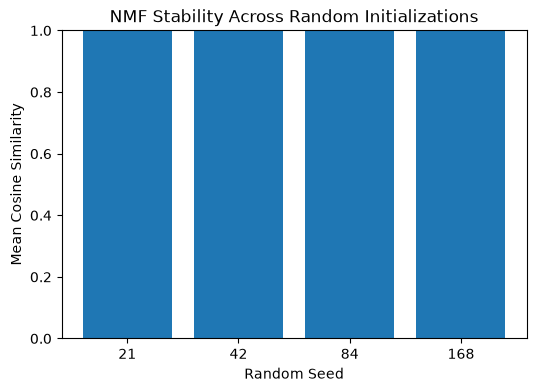

In [15]:
plt.figure(figsize=(6,4))

plt.bar(
    stability["Seed"].astype(str),
    stability["Mean_Cosine_Similarity"]
)

plt.ylim(0, 1)

plt.xlabel("Random Seed")
plt.ylabel("Mean Cosine Similarity")
plt.title("NMF Stability Across Random Initializations")

plt.show()